# 05 - Modelisation et evaluation

Ce notebook se lit **apres** `04_entrainement_complet.ipynb`, car il utilise les fichiers generes dans `reports/`.

Objectif : transformer les tableaux de resultats en analyse claire pour la presentation : comparaison des modeles, lecture des metriques, impact du seuil, faux positifs/faux negatifs et choix final.


## 1. Chargement des resultats

Les trois fichiers utilises ici sont :

- `baseline_analysis.csv` : montre pourquoi l'accuracy seule est trompeuse ;
- `model_comparison.csv` : compare les modeles et les strategies de desequilibre ;
- `threshold_analysis.csv` : montre comment les metriques changent quand on modifie le seuil de decision.


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
REPORTS_DIR = BASE_DIR / 'reports'

comparison = pd.read_csv(REPORTS_DIR / 'model_comparison.csv')
thresholds = pd.read_csv(REPORTS_DIR / 'threshold_analysis.csv')
baseline = pd.read_csv(REPORTS_DIR / 'baseline_analysis.csv')

pd.set_option('display.max_columns', None)
print('Modeles compares :', comparison.shape[0])
print('Seuils testes :', thresholds['threshold'].nunique())


Modeles compares : 9
Seuils testes : 17


## 2. Comment lire les colonnes importantes

- `modele` : nom de l'algorithme et parfois de la variante testee.
- `strategie_desequilibre` : technique utilisee pour traiter le desequilibre de classes.
- `test_accuracy` : part totale de predictions correctes. Attention, elle peut etre trompeuse si la classe majoritaire domine.
- `test_recall` : part des vrais churners detectes. C'est la metrique prioritaire ici.
- `test_precision` : parmi les clients alertes, part de vrais churners.
- `test_f1` : compromis entre precision et recall.
- `test_roc_auc` : qualite generale du classement des probabilites.
- `test_pr_auc` : qualite du modele sur la classe positive rare ; tres utile ici.
- `test_fp` : faux positifs, clients alertes alors qu'ils ne churnent pas.
- `test_fn` : faux negatifs, clients non alertes alors qu'ils churnent. Ce sont les erreurs les plus couteuses metier.
- `threshold_recommande` : seuil final retenu pour transformer une probabilite en alerte.


## 3. Baseline : pourquoi l'accuracy ne suffit pas

La baseline majoritaire predit toujours `pas de churn`. Elle obtient une bonne accuracy parce que la majorite des clients ne churnent pas, mais elle ne detecte aucun churner.

A retenir pour la presentation : **une accuracy proche de 90 % peut cacher un recall de 0 %**.


In [4]:
baseline_display = baseline[[
    'modele', 'strategie_desequilibre', 'threshold', 'accuracy', 'precision', 'recall',
    'f1', 'tn', 'fp', 'fn', 'tp', 'clients_alertes', 'roc_auc', 'pr_auc'
]].copy()
baseline_display


,modele,strategie_desequilibre,threshold,accuracy,precision,recall,f1,tn,fp,fn,tp,clients_alertes,roc_auc,pr_auc
0,NaiveMajority,baseline_majoritaire,0.5,0.8980,0.000000,0.000000,0.000000,1796,0,204,0,0,NaN,NaN
1,LogisticRegression_baseline,aucun_reequilibrage,0.5,0.8955,0.413793,0.058824,0.103004,1779,17,192,12,29,0.747691,0.251169


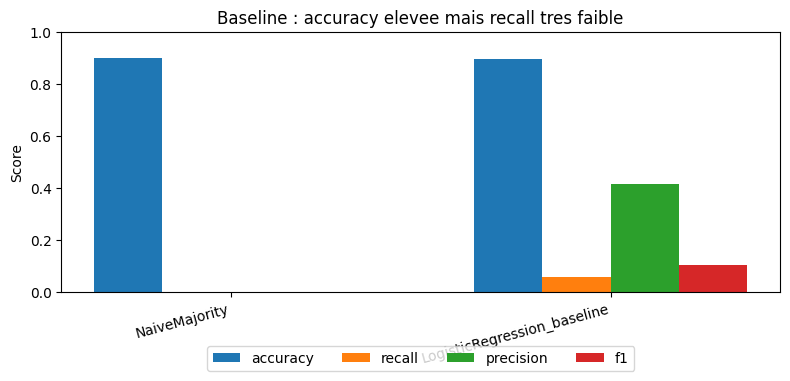

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
metrics = ['accuracy', 'recall', 'precision', 'f1']
x = np.arange(len(baseline_display['modele']))
width = 0.18

for i, metric in enumerate(metrics):
    ax.bar(x + (i - 1.5) * width, baseline_display[metric], width, label=metric)

ax.set_xticks(x)
ax.set_xticklabels(baseline_display['modele'], rotation=15, ha='right')
ax.set_ylim(0, 1)
ax.set_title('Baseline : accuracy elevee mais recall tres faible')
ax.set_ylabel('Score')
ax.legend(ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.18))
plt.tight_layout()
plt.show()


## 4. Comparaison des strategies au seuil 0.5

Ce tableau compare les modeles au seuil standard `0.5`. Il permet de voir la performance brute avant optimisation du seuil.

Lecture rapide :

- un recall eleve signifie que le modele detecte plus de churners ;
- une precision elevee signifie que les alertes sont plus fiables ;
- une PR-AUC elevee est un bon signal dans un dataset desequilibre ;
- le nombre de `test_fn` doit rester bas car ce sont les churners rates.


In [6]:
main_cols = [
    'modele', 'strategie_desequilibre', 'test_accuracy', 'test_recall', 'test_precision',
    'test_f1', 'test_roc_auc', 'test_pr_auc', 'test_fp', 'test_fn', 'test_tp', 'test_tn',
    'best_f1_threshold', 'best_f1'
]
comparison_display = comparison[main_cols].sort_values(['test_recall', 'test_pr_auc'], ascending=False)
comparison_display


,modele,strategie_desequilibre,test_accuracy,test_recall,test_precision,test_f1,test_roc_auc,test_pr_auc,test_fp,test_fn,test_tp,test_tn,best_f1_threshold,best_f1
0,XGBoost_scale_pos_weight,scale_pos_weight,0.7745,0.696078,0.267420,0.386395,0.796615,0.281602,389,62,142,1407,0.50,0.386395
1,LogisticRegression_class_weight,class_weight_balanced,0.6880,0.671569,0.197406,0.305122,0.750033,0.251288,557,67,137,1239,0.75,0.331683
2,LogisticRegression_random_over,random_over_sampling,0.6925,0.666667,0.199122,0.306652,0.746015,0.246112,547,68,136,1249,0.70,0.327122
3,LogisticRegression_random_under,random_under_sampling,0.6830,0.661765,0.192857,0.298673,0.739440,0.244048,565,69,135,1231,0.55,0.320611
4,LogisticRegression_smote,smote,0.6810,0.651961,0.190000,0.294248,0.741231,0.246818,567,71,133,1229,0.60,0.324561
5,RandomForest_class_weight,class_weight_balanced_subsample,0.8530,0.377451,0.315574,0.343750,0.798002,0.262276,167,127,77,1629,0.35,0.392390
6,DeepLearning_smote,smote,0.8370,0.279412,0.241525,0.259091,0.699318,0.207502,179,147,57,1617,0.20,0.312030
7,LogisticRegression_baseline,aucun_reequilibrage,0.8955,0.058824,0.413793,0.103004,0.747691,0.251169,17,192,12,1779,0.15,0.321373
8,RandomForest_baseline,aucun_reequilibrage,0.8980,0.000000,0.000000,0.000000,0.805013,0.324355,0,204,0,1796,0.20,0.387650


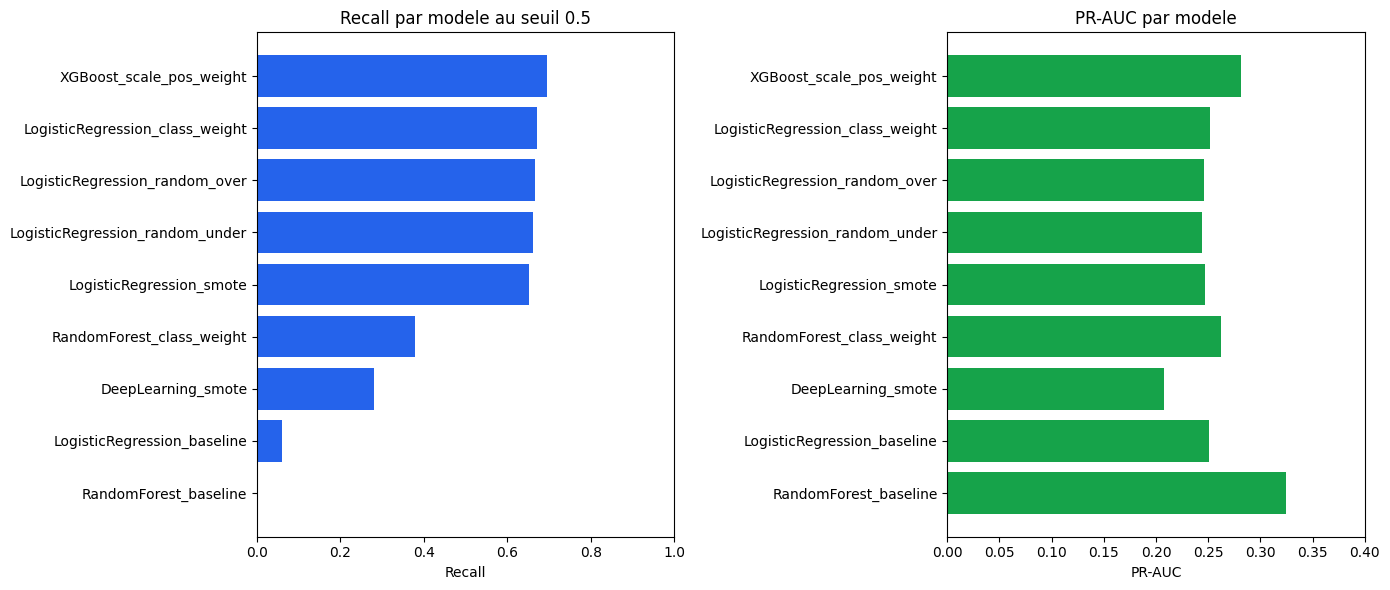

In [7]:
plot_df = comparison.sort_values('test_recall', ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(plot_df['modele'], plot_df['test_recall'], color='#2563eb')
axes[0].set_title('Recall par modele au seuil 0.5')
axes[0].set_xlabel('Recall')
axes[0].set_xlim(0, 1)

axes[1].barh(plot_df['modele'], plot_df['test_pr_auc'], color='#16a34a')
axes[1].set_title('PR-AUC par modele')
axes[1].set_xlabel('PR-AUC')
axes[1].set_xlim(0, max(0.4, plot_df['test_pr_auc'].max() + 0.05))

plt.tight_layout()
plt.show()


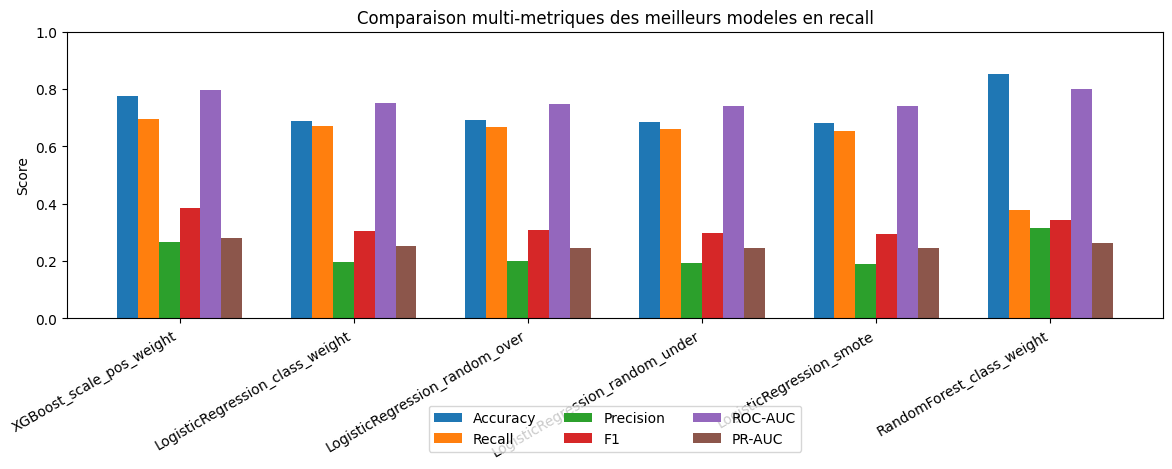

In [8]:
metric_cols = ['test_accuracy', 'test_recall', 'test_precision', 'test_f1', 'test_roc_auc', 'test_pr_auc']
metric_labels = ['Accuracy', 'Recall', 'Precision', 'F1', 'ROC-AUC', 'PR-AUC']
ordered = comparison.sort_values('test_recall', ascending=False).head(6)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(ordered))
width = 0.12

for i, col in enumerate(metric_cols):
    ax.bar(x + (i - 2.5) * width, ordered[col], width, label=metric_labels[i])

ax.set_xticks(x)
ax.set_xticklabels(ordered['modele'], rotation=30, ha='right')
ax.set_ylim(0, 1)
ax.set_title('Comparaison multi-metriques des meilleurs modeles en recall')
ax.set_ylabel('Score')
ax.legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.28))
plt.tight_layout()
plt.show()


## 5. Faux positifs et faux negatifs

Dans le contexte metier, les faux negatifs sont les plus graves : ce sont des clients qui vont churner mais que le modele ne signale pas.

Les faux positifs representent des clients alertes inutilement. Ils ont un cout operationnel, mais ce cout peut etre acceptable si une campagne de retention est peu couteuse.


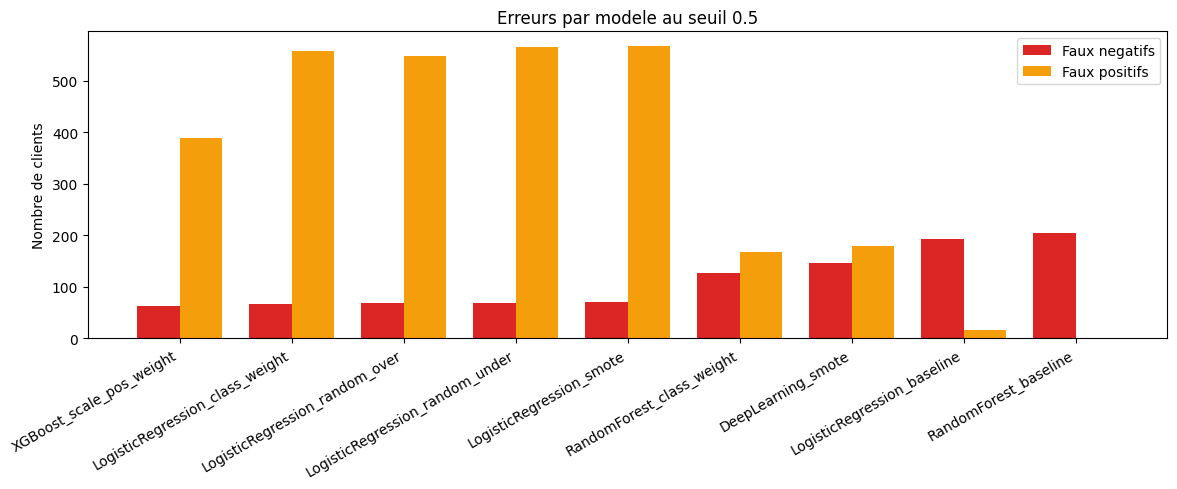

In [9]:
error_df = comparison.sort_values('test_fn', ascending=True)
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(error_df))
width = 0.38

ax.bar(x - width/2, error_df['test_fn'], width, label='Faux negatifs', color='#dc2626')
ax.bar(x + width/2, error_df['test_fp'], width, label='Faux positifs', color='#f59e0b')
ax.set_xticks(x)
ax.set_xticklabels(error_df['modele'], rotation=30, ha='right')
ax.set_title('Erreurs par modele au seuil 0.5')
ax.set_ylabel('Nombre de clients')
ax.legend()
plt.tight_layout()
plt.show()


## 6. Impact du seuil de decision

Un modele produit une probabilite de churn. Le seuil transforme cette probabilite en classe :

- si `proba_churn >= seuil`, le client est alerte ;
- si `proba_churn < seuil`, le client n'est pas alerte.

Baisser le seuil augmente generalement le recall, mais cree plus de faux positifs. Monter le seuil augmente souvent la precision, mais rate plus de churners.


In [10]:
final_row = comparison[comparison['modele_final'] == True].iloc[0]
final_model = final_row['modele']
recommended_threshold = float(final_row['threshold_recommande'])
final_thresholds = thresholds[thresholds['modele'] == final_model].sort_values('threshold')

print('Modele final :', final_model)
print('Strategie :', final_row['strategie_desequilibre'])
print('Seuil recommande :', recommended_threshold)
final_thresholds[['threshold', 'recall', 'precision', 'f1', 'accuracy', 'fp', 'fn', 'tp', 'tn', 'clients_alertes']].head(10)


Modele final : XGBoost_scale_pos_weight
Strategie : scale_pos_weight
Seuil recommande : 0.2


,threshold,recall,precision,f1,accuracy,fp,fn,tp,tn,clients_alertes
16,0.10,0.941176,0.129642,0.227893,0.3495,1289,12,192,507,1481
23,0.15,0.897059,0.176471,0.294923,0.5625,854,21,183,942,1037
25,0.20,0.882353,0.210773,0.340265,0.6510,674,24,180,1122,854
33,0.25,0.848039,0.225554,0.356334,0.6875,594,31,173,1202,767
32,0.30,0.848039,0.242637,0.377317,0.7145,540,31,173,1256,713
39,0.35,0.803922,0.244048,0.374429,0.7260,508,40,164,1288,672
42,0.40,0.774510,0.247649,0.375297,0.7370,480,46,158,1316,638
43,0.45,0.745098,0.258065,0.383354,0.7555,437,52,152,1359,589
47,0.50,0.696078,0.267420,0.386395,0.7745,389,62,142,1407,531
55,0.55,0.632353,0.276824,0.385075,0.7940,337,75,129,1459,466


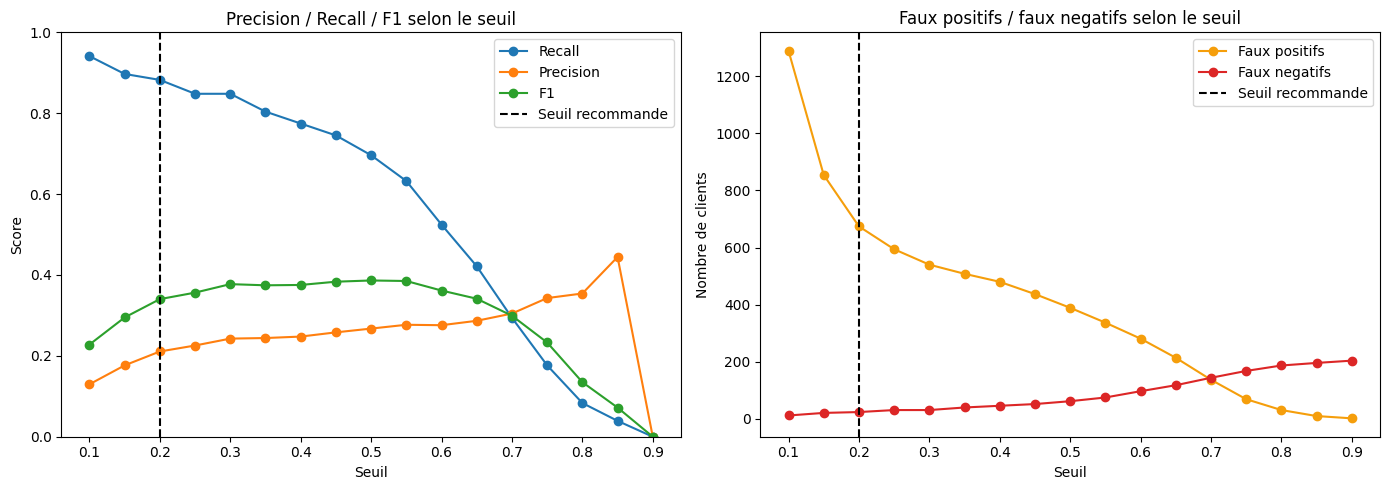

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(final_thresholds['threshold'], final_thresholds['recall'], marker='o', label='Recall')
axes[0].plot(final_thresholds['threshold'], final_thresholds['precision'], marker='o', label='Precision')
axes[0].plot(final_thresholds['threshold'], final_thresholds['f1'], marker='o', label='F1')
axes[0].axvline(recommended_threshold, color='black', linestyle='--', label='Seuil recommande')
axes[0].set_title('Precision / Recall / F1 selon le seuil')
axes[0].set_xlabel('Seuil')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].legend()

axes[1].plot(final_thresholds['threshold'], final_thresholds['fp'], marker='o', label='Faux positifs', color='#f59e0b')
axes[1].plot(final_thresholds['threshold'], final_thresholds['fn'], marker='o', label='Faux negatifs', color='#dc2626')
axes[1].axvline(recommended_threshold, color='black', linestyle='--', label='Seuil recommande')
axes[1].set_title('Faux positifs / faux negatifs selon le seuil')
axes[1].set_xlabel('Seuil')
axes[1].set_ylabel('Nombre de clients')
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Graphique etoile des meilleurs modeles

Ce graphique radar compare les meilleurs modeles selon plusieurs criteres.

Comment le lire : plus la surface est grande et equilibree, plus le modele est solide globalement. Mais pour notre projet, le recall reste prioritaire, meme si la precision est plus faible.


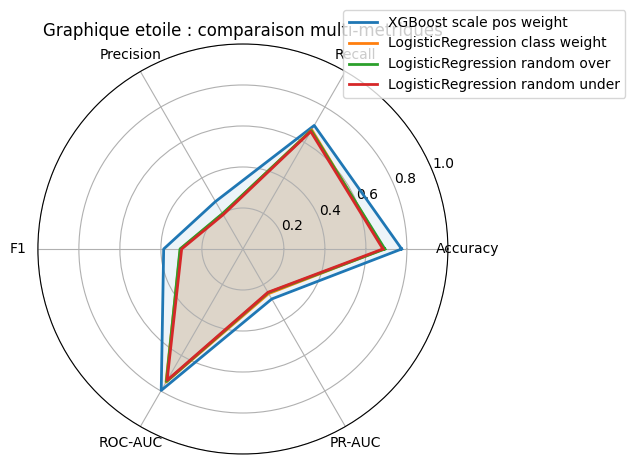

In [12]:
radar_metrics = ['test_accuracy', 'test_recall', 'test_precision', 'test_f1', 'test_roc_auc', 'test_pr_auc']
radar_labels = ['Accuracy', 'Recall', 'Precision', 'F1', 'ROC-AUC', 'PR-AUC']
radar_models = comparison.sort_values(['modele_final', 'test_recall', 'test_pr_auc'], ascending=False).head(4)

angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})
for _, row in radar_models.iterrows():
    values = row[radar_metrics].astype(float).tolist()
    values += values[:1]
    label = row['modele'].replace('_', ' ')
    ax.plot(angles, values, linewidth=2, label=label)
    ax.fill(angles, values, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels)
ax.set_ylim(0, 1)
ax.set_title('Graphique etoile : comparaison multi-metriques')
ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.10))
plt.tight_layout()
plt.show()


## 8. Explicabilite du modele final

On ajoute trois niveaux d'explication, du plus simple au plus avance :

- **`feature_importances_`** : importance native apres entrainement, basique et rapide, surtout pour les modeles d'arbres.
- **Permutation Importance** : importance apres evaluation, recommandee car elle mesure la perte de performance quand une variable est melangee.
- **SHAP** : explication avancee du modele final selectionne, utile pour comprendre l'impact moyen des variables sur les predictions.

Ces graphiques sont ceux repris dans l'onglet `Explication` de l'application Streamlit.


In [13]:
import joblib
from sklearn.inspection import permutation_importance

try:
    import shap
except ImportError:
    shap = None

MODEL_PATH = BASE_DIR / 'models' / 'best_model.pkl'
PREPROCESSED_PATH = BASE_DIR / 'data_preprocessed.pkl'

best_model = joblib.load(MODEL_PATH)
preprocessed = joblib.load(PREPROCESSED_PATH)
X_test = preprocessed['X_test']
y_test = preprocessed['y_test']

sample_size = min(500, len(X_test))
X_sample = X_test.iloc[:sample_size]
y_sample = y_test.iloc[:sample_size]

print('Modele final charge :', preprocessed.get('modele_retenu'))
print('Strategie retenue :', preprocessed.get('strategie_retenue'))
print('Seuil recommande :', preprocessed.get('threshold_recommande'))


Modele final charge : XGBoost_scale_pos_weight
Strategie retenue : scale_pos_weight
Seuil recommande : 0.2


### 8.1 Feature importances natives apres entrainement

Cette methode lit directement l'attribut `feature_importances_` du modele final. Elle est simple a expliquer : plus la barre est grande, plus la variable a ete utilisee par le modele.

Limite : cette importance est interne au modele et ne mesure pas directement la perte de performance metier.


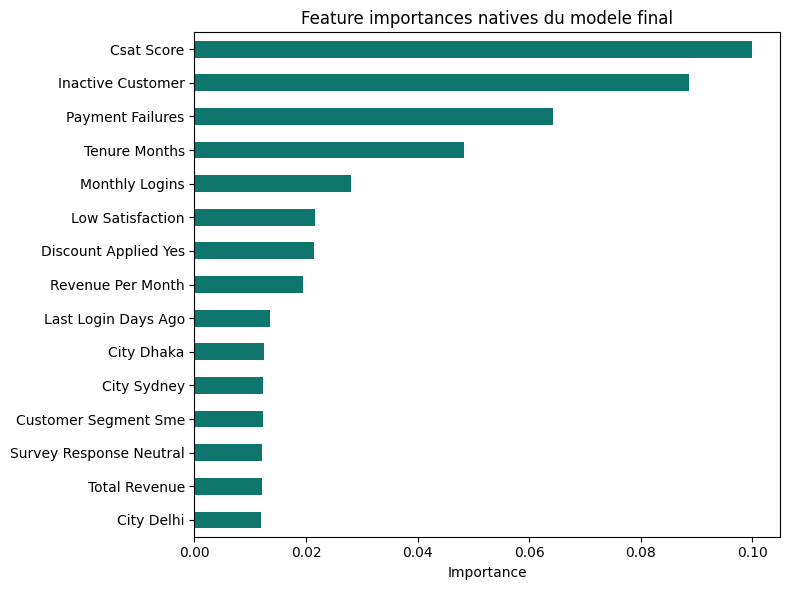

In [14]:
def format_feature_name(name):
    return str(name).replace('num__', '').replace('cat__', '').replace('_', ' ').title()


def get_transformed_feature_names(model, X_sample):
    preprocessor = model.named_steps.get('pre')
    if preprocessor is None:
        return X_sample.columns.tolist()
    try:
        return preprocessor.get_feature_names_out()
    except AttributeError:
        return X_sample.columns.tolist()

estimator = best_model.named_steps.get('model')
if hasattr(estimator, 'feature_importances_'):
    feature_names = get_transformed_feature_names(best_model, X_sample)
    native_importances = pd.Series(estimator.feature_importances_, index=feature_names)
    top_native = native_importances.sort_values(ascending=False).head(15).sort_values()

    fig, ax = plt.subplots(figsize=(8, 6))
    top_native.rename(index=format_feature_name).plot(kind='barh', ax=ax, color='#0f766e')
    ax.set_title('Feature importances natives du modele final')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print('Le modele final ne fournit pas feature_importances_.')


### 8.2 Permutation Importance apres evaluation

Cette methode est recommandee pour l'analyse : on melange une variable, puis on regarde combien le **recall** baisse.

Lecture : si une variable a une importance elevee, cela signifie qu'elle aide fortement a detecter les vrais churners.


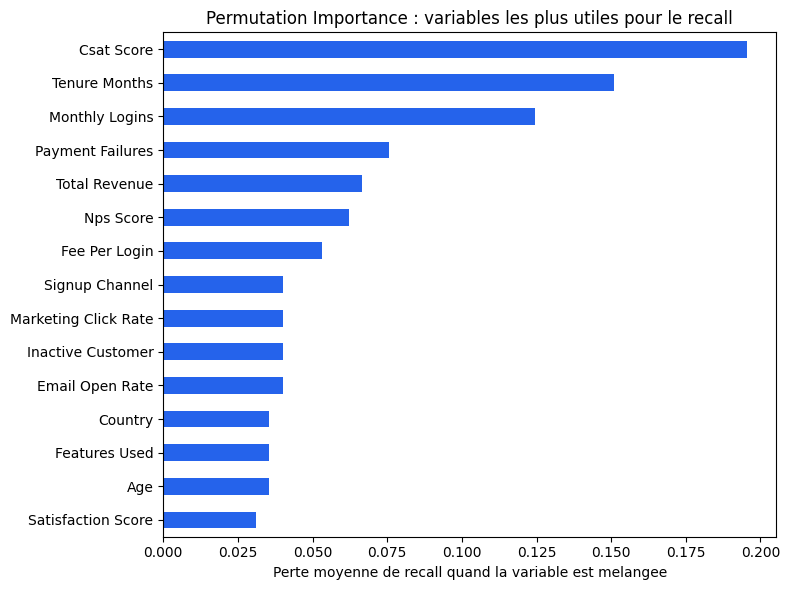

In [15]:
permutation_result = permutation_importance(
    best_model,
    X_sample,
    y_sample,
    scoring='recall',
    n_repeats=5,
    random_state=42,
)

permutation_top = (
    pd.Series(permutation_result.importances_mean, index=X_test.columns)
    .sort_values(ascending=False)
    .head(15)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 6))
permutation_top.rename(index=format_feature_name).plot(kind='barh', ax=ax, color='#2563eb')
ax.set_title('Permutation Importance : variables les plus utiles pour le recall')
ax.set_xlabel('Perte moyenne de recall quand la variable est melangee')
plt.tight_layout()
plt.show()


### 8.3 SHAP sur le modele final selectionne

SHAP est plus avance : il estime l'impact moyen de chaque variable sur les predictions du modele final.

Lecture : plus la valeur SHAP moyenne absolue est grande, plus la variable influence les predictions. C'est utile pour expliquer le modele final de maniere plus fine.


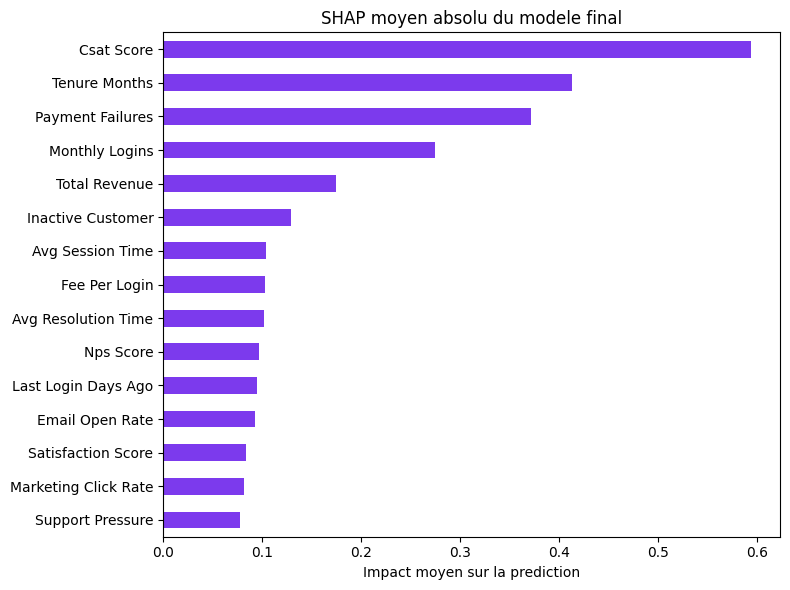

In [17]:
if shap is None:
    print('SHAP n est pas installe dans cet environnement.')
else:
    preprocessor = best_model.named_steps.get('pre')
    estimator = best_model.named_steps.get('model')
    transformed_sample = preprocessor.transform(X_sample)
    feature_names = get_transformed_feature_names(best_model, X_sample)

    explainer = shap.TreeExplainer(estimator)
    shap_values = explainer.shap_values(transformed_sample)
    if isinstance(shap_values, list):
        shap_values = shap_values[-1]

    shap_top = (
        pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names)
        .sort_values(ascending=False)
        .head(15)
        .sort_values()
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    shap_top.rename(index=format_feature_name).plot(kind='barh', ax=ax, color='#7c3aed')
    ax.set_title('SHAP moyen absolu du modele final')
    ax.set_xlabel('Impact moyen sur la prediction')
    plt.tight_layout()
    plt.show()


## 9. Conclusion pour la presentation

A retenir :

- Le dataset est desequilibre, donc l'accuracy seule n'est pas fiable.
- Les techniques de desequilibre ameliorent fortement la detection des churners.
- Le meilleur choix final est `XGBoost_scale_pos_weight` avec un seuil `0.20`.
- Ce choix detecte beaucoup de churners, avec un recall d'environ `88.2 %` au seuil recommande.
- Le compromis est clair : moins de faux negatifs, mais plus de faux positifs.
- En retention client, ce compromis est defensible si le cout d'une action marketing est inferieur au cout d'un client perdu.
